# Preparación del Dataset
**Notebook 02:** Corrección de desbalance + detección de duplicados

Este notebook cubre dos problemas críticos detectados en el EDA:
1. **Clase `normal_skin` casi vacía** (23 anotaciones) -> añadir imágenes de CelebA
2. **Clase de ojeras, manchas, arrugas y demás con pocas anotaciones** -> añadir imagenes de Roboflow
3. **Posibles duplicados** en el dataset -> detectar y eliminar antes de entrenar
4. **Posibles imagenes borrosas** -> mejorar su nitidez 

## 1. Setup e imports

In [ ]:
import os, sys, shutil, hashlib, json, yaml, random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
import cv2
from tqdm import tqdm
from roboflow import Roboflow



plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f8f9fa'

# ── Rutas base ──────────────────────────────────────────────────────────────
DATASET_PATH = Path("data")          # dataset original del EDA
CELEBA_PATH  = Path("data/celeba")   # donde se descargará CelebA
OUTPUT_PATH  = Path("data/clean")    # dataset final limpio

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
for split in ["train","valid","test"]:
    (OUTPUT_PATH / split / "images").mkdir(parents=True, exist_ok=True)
    (OUTPUT_PATH / split / "labels").mkdir(parents=True, exist_ok=True)

# ── Leer clases del data.yaml ───────────────────────────────────────────────
with open(DATASET_PATH / "data.yaml") as f:
    cfg = yaml.safe_load(f)
CLASSES     = cfg["names"]
NUM_CLASSES = len(CLASSES)
NORMAL_ID   = CLASSES.index("normal skin")   # id de la clase que ampliaremos

print(f"Dataset base:  {DATASET_PATH}")
print(f"CelebA path:   {CELEBA_PATH}")
print(f"Output limpio: {OUTPUT_PATH}")
print(f"Clases ({NUM_CLASSES}): {CLASSES}")
print(f"ID 'normal skin': {NORMAL_ID}")

Dataset base:  data
CelebA path:   data\celeba
Output limpio: data\clean
Clases (9): ['acne', 'dark circle', 'darkspot', 'dry', 'normal skin', 'oily', 'pores', 'skin redness', 'wrinkle']
ID 'normal skin': 4


In [11]:
def count_class_annotations(dataset_path, splits, n_classes):
    counts = defaultdict(int)
    for split in splits:
        ldir = Path(dataset_path) / split / "labels"
        if not ldir.exists():
            continue
        for lf in ldir.glob("*.txt"):
            for line in open(lf):
                p = line.strip().split()
                if p:
                    counts[int(p[0])] += 1
    return counts

counts = count_class_annotations(DATASET_PATH, ["train","valid","test"], NUM_CLASSES)

# 2. Integración de CelebA

CelebA tiene 202,599 imágenes de rostros de celebridades con landmarks y atributos.
Usaremos las imágenes alineadas (`img_align_celeba`) como fuente de piel normal.

In [ ]:
# Verificar que CelebA está disponible 
celeba_imgs_dir = CELEBA_PATH / "img_align_celeba"/ "img_align_celeba"
if celeba_imgs_dir.exists():
    n_celeba = len(list(celeba_imgs_dir.glob("*.jpg")))
    print(f"CelebA disponible: {n_celeba:,} imágenes en {celeba_imgs_dir}")
else:
    print(f" No se encontró CelebA en {celeba_imgs_dir}")
    print("   Descárgalo y vuelve a ejecutar desde la celda siguiente.")

CelebA disponible: 202,599 imágenes en data\celeba\img_align_celeba\img_align_celeba


## 2.1 Preprocesado de imágenes CelebA

Pipeline para cada imagen de CelebA:
1. Detectar rostro con Viola-Jones (Haar Cascade)
2. Cargar el archivo de atributos de CelebA
3. Recortar con padding y redimensionar a 640×640
4. Generar label YOLO con bbox = cara completa (`normal_skin`)
5. Guardar en la carpeta de train del dataset

In [ ]:
# Cargar clasificador de rostros 
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

def detect_face(img_bgr, scale=1.1, neighbors=5, min_size=(60,60)):
    """Devuelve la bbox del rostro más grande detectado, o None."""
    gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray  = cv2.equalizeHist(gray)    # mejora detección en imágenes oscuras
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor  = scale,
        minNeighbors = neighbors,
        minSize      = min_size
    )
    if len(faces) == 0:
        return None
    # Quedarse con el rostro más grande (mayor área)
    return max(faces, key=lambda f: f[2]*f[3])

def crop_and_resize(img_bgr, x, y, w, h, padding=40, target=640):
    """Recorta el rostro con padding y redimensiona a target×target."""
    ih, iw = img_bgr.shape[:2]
    x1 = max(0, x - padding)
    y1 = max(0, y - padding)
    x2 = min(iw, x + w + padding)
    y2 = min(ih, y + h + padding)
    crop = img_bgr[y1:y2, x1:x2]
    resized = cv2.resize(crop, (target, target), interpolation=cv2.INTER_AREA)
    return resized, (x1, y1, x2-x1, y2-y1), (iw, ih)

def bbox_to_yolo(x, y, w, h, iw, ih):
    """Convierte bbox absoluta a formato YOLO normalizado."""
    cx = (x + w/2) / iw
    cy = (y + h/2) / ih
    nw = w / iw
    nh = h / ih
    return cx, cy, nw, nh

print(" Funciones de preprocesado listas")
print(f"   Cascade: haarcascade_frontalface_default.xml")
print(f"   Target size: 640×640")

 Funciones de preprocesado listas
   Cascade: haarcascade_frontalface_default.xml
   Target size: 640×640


### Cargar el archivo de atributos de CelebA

In [45]:

# list_attr_celeba.txt tiene 40 atributos binarios por imagen.
# Valor  1 = tiene el atributo
# Valor -1 = no tiene el atributo

# Columnas relevantes para este filtro:
#   Bags_Under_Eyes : ojeras / bolsas bajo los ojos
#   Pale_Skin       : piel muy palida (excluir para variedad de tonos)
#   Heavy_Makeup    : maquillaje muy marcado (puede ocultar condiciones reales)

CELEBA_PATH   = Path("data/celeba")
ATTR_FILE     = CELEBA_PATH /"list_attr_celeba.csv"

# El archivo tiene una fila de cabecera con el total y otra con los nombres
# Formato: nombre_imagen  attr1  attr2 ... attr40
attr_df = pd.read_csv(
    ATTR_FILE,
    sep=",",
    header=0
)

print(f"Atributos disponibles: {list(attr_df.columns)}")
print(f"Total imagenes en CelebA: {len(attr_df)}")

Atributos disponibles: ['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young']
Total imagenes en CelebA: 202599


In [46]:
# Comprobar tabla de atributos
print("Primeras 3 filas del DataFrame:")
print(attr_df.head(3))
print()
print("Columnas disponibles:")
print(list(attr_df.columns))
print()
print("Tipo del indice:", type(attr_df.index[0]))
print("Primeros valores del indice:", list(attr_df.index[:3]))

Primeras 3 filas del DataFrame:
     image_id  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
0  000001.jpg                -1                1           1               -1   
1  000002.jpg                -1               -1          -1                1   
2  000003.jpg                -1               -1          -1               -1   

   Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  ...  Sideburns  Smiling  \
0    -1     -1        -1        -1          -1  ...         -1        1   
1    -1     -1        -1         1          -1  ...         -1        1   
2    -1     -1         1        -1          -1  ...         -1       -1   

   Straight_Hair  Wavy_Hair  Wearing_Earrings  Wearing_Hat  Wearing_Lipstick  \
0              1         -1                 1           -1                 1   
1             -1         -1                -1           -1                -1   
2             -1          1                -1           -1                -1   

   Wearing_Necklace  

Filtrado de dataset celebA para ampliar la clase normal 

In [ ]:
# Filtrar imagenes aptas para normal_skin 
# Condiciones de inclusion (valor = -1 significa que NO tiene ese atributo):

#   Bags_Under_Eyes == -1   no tiene ojeras

normal_skin_candidates = attr_df[
    (attr_df["Bags_Under_Eyes"] == -1) &
    (attr_df["Heavy_Makeup"]  == -1) 
]

print(f"Imagenes aptas para normal_skin: {len(normal_skin_candidates):,}")
print(f"Imagenes descartadas:            {len(attr_df) - len(normal_skin_candidates):,}")

# Mezclar aleatoriamente para no tomar siempre las mismas
normal_skin_candidates = normal_skin_candidates.sample(
    frac=1, random_state=42
).reset_index()

Imagenes aptas para normal_skin: 87,124
Imagenes descartadas:            115,475


Procesar imagenes y cargarlas al dataset como clase normal

In [ ]:
#  Procesar imágenes CelebA Filtradas 
TARGET_NORMAL  = 21500     # cuántas imágenes de normal skin queremos añadir
PADDING        = 40      # px de contexto alrededor del rostro
OUTPUT_IMG_DIR = OUTPUT_PATH / "train" / "images"
OUTPUT_LBL_DIR = OUTPUT_PATH / "train" / "labels"

# Crear directorios de salida por seguridad si no existen
OUTPUT_IMG_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_LBL_DIR.mkdir(parents=True, exist_ok=True)

if not celeba_imgs_dir.exists():
    print(" CelebA no encontrado. Ejecuta la descarga primero.")
else:
    # MODIFICACIÓN: Buscamos la columna que tiene el nombre del archivo (ej: '000001.jpg')
    # Si al hacer reset_index() tu columna se llama 'image_id', usa: normal_skin_candidates['image_id']
    # Si era el índice original, tras reset_index() se llama 'index'. Aquí evaluamos ambos casos de forma segura:
    col_name = "image_id" if "image_id" in normal_skin_candidates.columns else "index"
    
    # Extraemos la lista de nombres de archivos válidos
    valid_filenames = normal_skin_candidates[col_name].tolist()
    
    processed = 0
    skipped_no_face = 0
    skipped_error   = 0

    # Cambiamos el bucle para iterar sobre los nombres de archivos aptos filtrados en el CODIGO 1
    pbar = tqdm(valid_filenames, desc="Procesando CelebA (Aptos)")
    for img_name in pbar:
        if processed >= TARGET_NORMAL:
            break
            
        # Construimos la ruta completa usando la carpeta original de imágenes y el nombre apto
        img_path = celeba_imgs_dir / str(img_name)
        
        try:
            img = cv2.imread(str(img_path))
            if img is None:
                skipped_error += 1
                continue

            face = detect_face(img)
            if face is None:
                skipped_no_face += 1
                continue

            x, y, w, h = face
            cropped, (cx, cy, cw, ch), (iw, ih) = crop_and_resize(img, x, y, w, h, PADDING)

            # Nombre único para no colisionar con el dataset original
            stem = f"celeba_normal_{processed:05d}"

            # Guardar imagen
            cv2.imwrite(str(OUTPUT_IMG_DIR / f"{stem}.jpg"), cropped)

            # Generar label YOLO (bbox ocupa casi toda la imagen tras el crop)
            face_in_crop_x = PADDING
            face_in_crop_y = PADDING
            face_in_crop_w = w
            face_in_crop_h = h
            full_w = cw
            full_h = ch
            yolo_cx, yolo_cy, yolo_w, yolo_h = bbox_to_yolo(
                face_in_crop_x, face_in_crop_y,
                face_in_crop_w, face_in_crop_h,
                full_w, full_h
            )
            
            # Clamp a [0,1]
            yolo_cx = min(max(yolo_cx, 0.0), 1.0)
            yolo_cy = min(max(yolo_cy, 0.0), 1.0)
            yolo_w  = min(max(yolo_w,  0.0), 1.0)
            yolo_h  = min(max(yolo_h,  0.0), 1.0)

            with open(OUTPUT_LBL_DIR / f"{stem}.txt", "w") as f:
                f.write(f"{NORMAL_ID} {yolo_cx:.6f} {yolo_cy:.6f} {yolo_w:.6f} {yolo_h:.6f}\n")

            processed += 1
            pbar.set_postfix({"OK": processed, "sin_cara": skipped_no_face})

        except Exception as e:
            skipped_error += 1

    print(f"\n Imágenes de normal_skin generadas exitosamente: {processed}")
    print(f"   Sin cara detectada en el recorte (descartadas): {skipped_no_face}")
    print(f"   Errores de lectura/archivo:                     {skipped_error}")
    print(f"   Guardadas en: {OUTPUT_IMG_DIR}")

Procesando CelebA (Aptos):  27%|██▋       | 23755/87124 [12:22<33:01, 31.99it/s, OK=21500, sin_cara=2255]  


 Imágenes de normal_skin generadas exitosamente: 21500
   Sin cara detectada en el recorte (descartadas): 2255
   Errores de lectura/archivo:                     0
   Guardadas en: data\clean\train\images


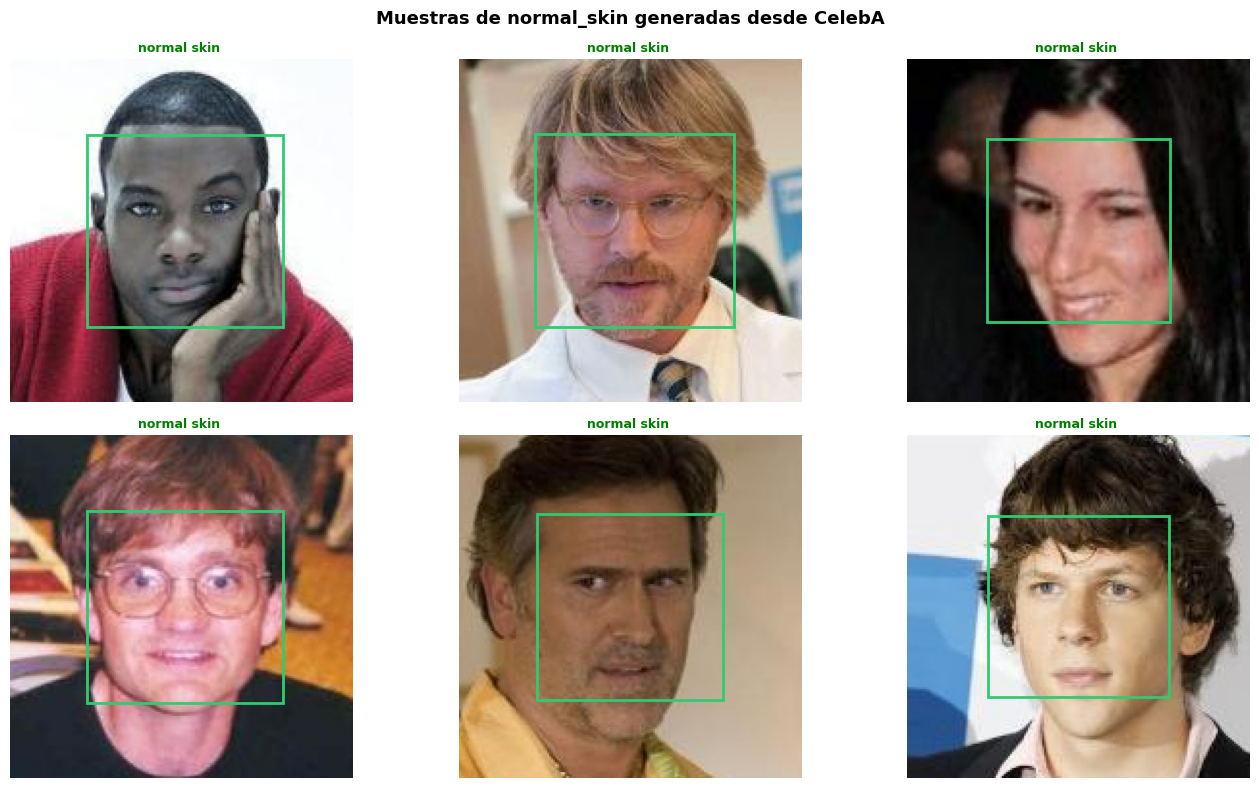

In [49]:
# Visualizar 6 muestras de lo generado
celeba_samples = list(OUTPUT_IMG_DIR.glob("celeba_normal_*.jpg"))[:6]

if celeba_samples:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    fig.suptitle("Muestras de normal_skin generadas desde CelebA", fontsize=13, fontweight='bold')

    for ax, img_path in zip(axes.flat, celeba_samples):
        img   = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        lpath = OUTPUT_LBL_DIR / (img_path.stem + ".txt")
        h, w  = img.shape[:2]

        ax.imshow(img)
        if lpath.exists():
            with open(lpath) as f:
                parts = f.read().strip().split()
            if len(parts) == 5:
                _, cx, cy, bw, bh = map(float, parts)
                x1 = int((cx - bw/2) * w); y1 = int((cy - bh/2) * h)
                x2 = int((cx + bw/2) * w); y2 = int((cy + bh/2) * h)
                rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                          linewidth=2, edgecolor='#2ECC71', facecolor='none')
                ax.add_patch(rect)
                ax.set_title("normal skin ", fontsize=9, color='green', fontweight='bold')
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("results/reports/06_celeba_samples.png", dpi=120, bbox_inches='tight')
    plt.show()
else:
    print("No se encontraron imágenes generadas todavía.")

In [ ]:
#  Copiar dataset original a data/clean 
print("Copiando dataset original a data/clean ...")

for split in ["train", "valid", "test"]:
    for subdir in ["images", "labels"]:
        src = DATASET_PATH / split / subdir
        dst = OUTPUT_PATH  / split / subdir
        if not src.exists():
            print(f"  No existe: {src}")
            continue
        files = list(src.glob("*"))
        for f in tqdm(files, desc=f"  {split}/{subdir}", leave=False):
            shutil.copy2(f, dst / f.name)

print("\n Dataset original copiado.")
print(f"   CelebA (train) ya está en {OUTPUT_PATH / 'train' / 'images'}")

Copiando dataset original a data/clean ...



 Dataset original copiado.
   CelebA (train) ya está en data\clean\train\images


In [ ]:
#Crear data.yaml para el dataset limpio
clean_yaml = {
    "path": str(OUTPUT_PATH.resolve()),
    "train": "train/images",
    "val":   "valid/images",
    "test":  "test/images",
    "nc":    NUM_CLASSES,
    "names": CLASSES
}

with open(OUTPUT_PATH / "data.yaml", "w") as f:
    yaml.dump(clean_yaml, f, default_flow_style=False, allow_unicode=True)

print(" data.yaml creado en", OUTPUT_PATH / "data.yaml")
print(json.dumps(clean_yaml, indent=2, ensure_ascii=False))

 data.yaml creado en data\clean\data.yaml
{
  "path": "C:\\Users\\lesli\\Documents\\computer vision\\Trabajo final\\data\\clean",
  "train": "train/images",
  "val": "valid/images",
  "test": "test/images",
  "nc": 9,
  "names": [
    "acne",
    "dark circle",
    "darkspot",
    "dry",
    "normal skin",
    "oily",
    "pores",
    "skin redness",
    "wrinkle"
  ]
}


In [ ]:
# Recuento post-integración 
counts_after = count_class_annotations(OUTPUT_PATH, ["train","valid","test"], NUM_CLASSES)

print("Anotaciones por clase (DESPUÉS de añadir CelebA):")
print("-" * 55)
for i, cls in enumerate(CLASSES):
    before = counts[i]
    after  = counts_after[i]
    delta  = after - before
    bar    = "█" * int(counts_after[i] / max(counts_after.values()) * 30)
    tag    = f" (+{delta})" if delta > 0 else ""
    print(f"  [{i}] {cls:15s} {after:6d} {tag:8s} {bar}")

ratio_after = max(counts_after.values()) / max(min(counts_after.values()),1)
print(f"\nRatio desbalance: {max(counts.values())/max(min(counts.values()),1):.0f}× → {ratio_after:.0f}×")

Anotaciones por clase (DESPUÉS de añadir CelebA):
-------------------------------------------------------
  [0] acne             22340          ██████████████████████████████
  [1] dark circle        513          
  [2] darkspot           124          
  [3] dry               2123          ██
  [4] normal skin      21523  (+21500) ████████████████████████████
  [5] oily               950          █
  [6] pores              702          
  [7] skin redness       123          
  [8] wrinkle           2377          ███

Ratio desbalance: 971× → 182×


### Ampliar clase dark_circle usando CelebA filtrado 

In [53]:
# Filtramos por Bags_Under_Eyes == 1 (tiene ojeras) y excluimos condiciones
# que interfieran con la deteccion: sombrero, gafas de sol, oclusiones.
#
# Tambien excluimos Smiling con valor extremo porque la sonrisa levanta
# los musculos periorbitales y puede ocultar las ojeras.

dark_circle_candidates = attr_df[
    (attr_df["Bags_Under_Eyes"]   ==  1) &
    (attr_df["Wearing_Hat"]       == -1) &
    (attr_df["Bald"]              == -1) &
    # Eyeglasses puede ocluir la zona periorbital, mejor excluir
    (attr_df["Eyeglasses"]        == -1)
]

print(f"Candidatos con ojeras (Bags_Under_Eyes=1): {len(dark_circle_candidates):,}")

dark_circle_candidates = dark_circle_candidates.sample(
    frac=1, random_state=7
).reset_index()

Candidatos con ojeras (Bags_Under_Eyes=1): 35,841


In [ ]:
# Generar imagenes de dark_circle desde CelebA
# BUGS CORREGIDOS respecto a la version anterior:


DARK_CIRCLE_ID     = CLASSES.index("dark circle")
TARGET_DARK_CIRCLE = 15000
PADDING_DC         = 30

OUTPUT_IMG_DIR = OUTPUT_PATH / "train" / "images"
OUTPUT_LBL_DIR = OUTPUT_PATH / "train" / "labels"

processed_dc  = 0
skipped_no_img = 0
skipped_dc_nf  = 0

pbar = tqdm(dark_circle_candidates.itertuples(),
            total=len(dark_circle_candidates),
            desc="dark_circle desde CelebA")

for row in pbar:
    if processed_dc >= TARGET_DARK_CIRCLE:
        break

    img_filename = row.image_id

    img_path = celeba_imgs_dir / img_filename

    if not img_path.exists():
        skipped_no_img += 1
        continue

    img = cv2.imread(str(img_path))
    if img is None:
        skipped_no_img += 1
        continue

    face = detect_face(img)
    if face is None:
        skipped_dc_nf += 1
        continue

    x, y, w, h = face
    cropped, (cx, cy, cw, ch), _ = crop_and_resize(img, x, y, w, h, PADDING_DC)

    # DETECTAR LA OJERA EN LA ZONA DE LOS OJOS
    # La bbox cubre la zona periorbital inferior:
    # centrada horizontalmente, en el tercio medio vertical del crop facial.
    # Es una aproximacion geometrica suficiente para el entrenamiento de YOLO.
    eye_region_cx = 0.5
    eye_region_cy = 0.50
    eye_region_w  = min(w / cw,        0.90)
    eye_region_h  = min((h * 0.35) / ch, 0.40)

    stem = f"celeba_darkcircle_{processed_dc:05d}"

    cv2.imwrite(str(OUTPUT_IMG_DIR / f"{stem}.jpg"), cropped,
                [cv2.IMWRITE_JPEG_QUALITY, 95])

    with open(OUTPUT_LBL_DIR / f"{stem}.txt", "w") as f:
        f.write(f"{DARK_CIRCLE_ID} "
                f"{eye_region_cx:.6f} {eye_region_cy:.6f} "
                f"{eye_region_w:.6f} {eye_region_h:.6f}\n")

    processed_dc += 1
    pbar.set_postfix({"OK": processed_dc, "sin_cara": skipped_dc_nf})

print(f"\ndark_circle generadas (CelebA): {processed_dc}")
print(f"Archivo no encontrado:           {skipped_no_img}")
print(f"Sin cara detectada:              {skipped_dc_nf}")

dark_circle desde CelebA:  43%|████▎     | 15359/35841 [09:13<12:17, 27.77it/s, OK=15000, sin_cara=359]


dark_circle generadas (CelebA): 15000
Archivo no encontrado:           0
Sin cara detectada:              359


In [ ]:
#Recuento post-integración 
counts_after = count_class_annotations(OUTPUT_PATH, ["train","valid","test"], NUM_CLASSES)

print("Anotaciones por clase (DESPUÉS de añadir CelebA):")
print("-" * 55)
for i, cls in enumerate(CLASSES):
    before = counts[i]
    after  = counts_after[i]
    delta  = after - before
    bar    = "█" * int(counts_after[i] / max(counts_after.values()) * 30)
    tag    = f" (+{delta})" if delta > 0 else ""
    print(f"  [{i}] {cls:15s} {after:6d} {tag:8s} {bar}")

ratio_after = max(counts_after.values()) / max(min(counts_after.values()),1)
print(f"\nRatio desbalance: {max(counts.values())/max(min(counts.values()),1):.0f}× → {ratio_after:.0f}×")

Anotaciones por clase (DESPUÉS de añadir CelebA):
-------------------------------------------------------
  [0] acne             22340          ██████████████████████████████
  [1] dark circle      15513  (+15000) ████████████████████
  [2] darkspot           124          
  [3] dry               2123          ██
  [4] normal skin      21523  (+21500) ████████████████████████████
  [5] oily               950          █
  [6] pores              702          
  [7] skin redness       123          
  [8] wrinkle           2377          ███

Ratio desbalance: 971× → 182×


## 3. Integracion de face_skin_condition (Roboflow)

Dataset: https://universe.roboflow.com/muhammad-rifqi-maruf/face_skin_condition  
Clases en el dataset: normal, acne, dry, oil, wrinkle  
Clases que usaremos (acne se omite — ya tenemos 22k)

In [ ]:
from dotenv import load_dotenv
load_dotenv()
import os

RF_API_KEY = os.getenv("ROBOFLOW_API_KEY")
rf = Roboflow(api_key=RF_API_KEY)

fsc_dataset = rf.workspace("muhammad-rifqi-maruf") \
                .project("face_skin_condition") \
                .version(1) \
                .download("yolov8", location="data/face_skin_condition")

print("Dataset descargado en data/face_skin_condition")

# Leer clases del data.yaml descargado
with open("data/face_skin_condition/data.yaml") as f:
    fsc_cfg = yaml.safe_load(f)

FSC_CLASSES = fsc_cfg["names"]
print(f"Clases del dataset ({len(FSC_CLASSES)}): {FSC_CLASSES}")

loading Roboflow workspace...
loading Roboflow project...
Dataset descargado en data/face_skin_condition
Clases del dataset (5): ['acne', 'dry', 'normal', 'oily', 'wrinkle']


In [57]:
# ── Mapeo de clases: face_skin_condition -> nuestro modelo ──────────────────
# None = omitir esa clase
FSC_CLASS_MAP = {}
for i, cls in enumerate(FSC_CLASSES):
    cls_lower = cls.lower().strip()
    if cls_lower == "normal":
        FSC_CLASS_MAP[i] = CLASSES.index("normal skin")
    elif cls_lower == "dry":
        FSC_CLASS_MAP[i] = CLASSES.index("dry")
    elif cls_lower in ("oil", "oily"):
        FSC_CLASS_MAP[i] = CLASSES.index("oily")
    elif cls_lower == "wrinkle":
        FSC_CLASS_MAP[i] = CLASSES.index("wrinkle")
    elif cls_lower == "acne":
        FSC_CLASS_MAP[i] = None   # omitir: ya tenemos 22k anotaciones
    else:
        FSC_CLASS_MAP[i] = None   # clase desconocida: omitir

print("Mapeo de clases:")
for src_id, dst_id in FSC_CLASS_MAP.items():
    src_name = FSC_CLASSES[src_id]
    dst_name = CLASSES[dst_id] if dst_id is not None else "OMITIDA"
    print(f"  [{src_id}] {src_name:12s} -> {dst_name}")

Mapeo de clases:
  [0] acne         -> OMITIDA
  [1] dry          -> dry
  [2] normal       -> normal skin
  [3] oily         -> oily
  [4] wrinkle      -> wrinkle


In [58]:
# ── Integrar imagenes de face_skin_condition en data/clean ──────────────────
def integrate_roboflow_dataset(src_base, class_map, dst_img_dir, dst_lbl_dir,
                                splits=("train","valid","test"), tag=""):
    """
    Copia imagenes de un dataset Roboflow descargado a data/clean,
    remapeando los IDs de clase segun class_map.

    Parametros
    ----------
    src_base   : Path al dataset descargado (contiene train/valid/test)
    class_map  : dict {id_origen: id_destino} (None = omitir clase)
    dst_img_dir: directorio destino de imagenes (data/clean/train/images)
    dst_lbl_dir: directorio destino de labels   (data/clean/train/labels)
    tag        : prefijo para los nombres de archivo generados
    """
    stats = {"copiadas": 0, "labels_vacias": 0, "errores": 0}

    for split in splits:
        src_img = Path(src_base) / split / "images"
        src_lbl = Path(src_base) / split / "labels"
        if not src_img.exists():
            continue

        img_files = list(src_img.glob("*.jpg")) + list(src_img.glob("*.png"))

        for img_path in tqdm(img_files, desc=f"  {tag} {split}", leave=False):
            lbl_path = src_lbl / (img_path.stem + ".txt")
            if not lbl_path.exists():
                continue

            # Leer y remapar labels
            new_lines = []
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    src_id = int(parts[0])
                    dst_id = class_map.get(src_id)
                    if dst_id is None:
                        continue   # clase omitida
                    new_lines.append(
                        f"{dst_id} {parts[1]} {parts[2]} {parts[3]} {parts[4]}"
                    )

            if not new_lines:
                stats["labels_vacias"] += 1
                continue

            # Nombre unico para evitar colisiones
            stem = f"{tag}_{split}_{img_path.stem}"

            # Redimensionar imagen a 640x640 si hace falta
            img = cv2.imread(str(img_path))
            if img is None:
                stats["errores"] += 1
                continue
            if img.shape[:2] != (640, 640):
                img = cv2.resize(img, (640, 640), interpolation=cv2.INTER_LANCZOS4)

            cv2.imwrite(str(dst_img_dir / f"{stem}.jpg"), img,
                        [cv2.IMWRITE_JPEG_QUALITY, 95])
            with open(dst_lbl_dir / f"{stem}.txt", "w") as f:
                f.write("\n".join(new_lines))

            stats["copiadas"] += 1

    return stats

# Ejecutar integracion
OUTPUT_IMG_DIR = OUTPUT_PATH / "train" / "images"
OUTPUT_LBL_DIR = OUTPUT_PATH / "train" / "labels"

stats_fsc = integrate_roboflow_dataset(
    src_base    = "data/face_skin_condition",
    class_map   = FSC_CLASS_MAP,
    dst_img_dir = OUTPUT_IMG_DIR,
    dst_lbl_dir = OUTPUT_LBL_DIR,
    tag         = "fsc"
)

print(f"face_skin_condition integrado:")
print(f"  Imagenes copiadas:   {stats_fsc['copiadas']}")
print(f"  Labels vacias:       {stats_fsc['labels_vacias']}")
print(f"  Errores:             {stats_fsc['errores']}")

face_skin_condition integrado:
  Imagenes copiadas:   1418
  Labels vacias:       293
  Errores:             0


In [59]:
# Recuento tras integrar face_skin_condition
counts_fsc = count_class_annotations(OUTPUT_PATH, ["train","valid","test"], NUM_CLASSES)
print("Anotaciones por clase tras face_skin_condition:")
for i, cls in enumerate(CLASSES):
    print(f"  [{i}] {cls:15s} {counts_fsc[i]:6d}")

Anotaciones por clase tras face_skin_condition:
  [0] acne             22340
  [1] dark circle      15513
  [2] darkspot           124
  [3] dry               2692
  [4] normal skin      22037
  [5] oily              1559
  [6] pores              702
  [7] skin redness       123
  [8] wrinkle           3044


## 4. Integracion de Dark_circle dataset (Roboflow)

Dataset: https://universe.roboflow.com/buyume-ahuro/dark_circle/dataset/1  
Clases: Acne, darkcicle, eyebag, pigmentation, spots, wrinkle



In [ ]:
# Descargar dark_circle dataset 

with open("data/dark_circle_r/data.yaml") as f:
    dc_cfg = yaml.safe_load(f)

DC_CLASSES = dc_cfg["names"]
print(f"Clases del dataset ({len(DC_CLASSES)}): {DC_CLASSES}")

# Mapeo de clases
DC_CLASS_MAP = {}
for i, cls in enumerate(DC_CLASSES):
    cls_lower = cls.lower().strip()
    if cls_lower == "acne":
        DC_CLASS_MAP[i] = None                         # omitir
    elif cls_lower in ("darkcircle", "dark_circle", "dark circle", "dark-circle"):
        DC_CLASS_MAP[i] = CLASSES.index("dark circle")
    elif cls_lower == "eyebag":
        DC_CLASS_MAP[i] = CLASSES.index("dark circle") # bolsas bajo ojos = dark circle
    elif cls_lower in ("pigmentation", "pigment"):
        DC_CLASS_MAP[i] = CLASSES.index("darkspot")
    elif cls_lower == "spots":
        DC_CLASS_MAP[i] = CLASSES.index("darkspot")
    elif cls_lower == "wrinkle":
        DC_CLASS_MAP[i] = CLASSES.index("wrinkle")
    else:
        DC_CLASS_MAP[i] = None

print("\nMapeo de clases:")
for src_id, dst_id in DC_CLASS_MAP.items():
    src_name = DC_CLASSES[src_id]
    dst_name = CLASSES[dst_id] if dst_id is not None else "OMITIDA"
    print(f"  [{src_id}] {src_name:15s} -> {dst_name}")

Clases del dataset (6): ['Acne', 'Eyebag', 'Wrinkle', 'darkcircle', 'pigmentation', 'spots']

Mapeo de clases:
  [0] Acne            -> OMITIDA
  [1] Eyebag          -> dark circle
  [2] Wrinkle         -> wrinkle
  [3] darkcircle      -> dark circle
  [4] pigmentation    -> darkspot
  [5] spots           -> darkspot


In [ ]:
def integrate_roboflow_dataset_fixed(src_base, class_map, dst_img_dir, dst_lbl_dir,
                                      splits=("train","valid","test"), tag=""):
    stats = {"copiadas": 0, "labels_vacias": 0, "errores": 0}

    for split in splits:
        src_img = Path(src_base) / split / "images"
        src_lbl = Path(src_base) / split / "labels"
        if not src_img.exists():
            continue

        img_files = list(src_img.glob("*.jpg")) + list(src_img.glob("*.png"))

        for img_path in tqdm(img_files, desc=f"   {tag} {split}", leave=False):
            lbl_path = src_lbl / (img_path.stem + ".txt")
            if not lbl_path.exists():
                continue

            new_lines = []
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    
                    
                    if len(parts) < 5:
                        continue
                        
                    src_id = int(parts[0])
                    dst_id = class_map.get(src_id)
                    if dst_id is None:
                        continue   # clase omitida
                    
                    # Tomamos estrictamente los primeros 5 elementos ignorando extras
                    new_lines.append(
                        f"{dst_id} {parts[1]} {parts[2]} {parts[3]} {parts[4]}"
                    )

            if not new_lines:
                stats["labels_vacias"] += 1
                continue

            # Nombre único para evitar colisiones
            stem = f"{tag}_{split}_{img_path.stem}"

            # Procesar imagen
            img = cv2.imread(str(img_path))
            if img is None:
                stats["errores"] += 1
                continue
                
            if img.shape[:2] != (640, 640):
                img = cv2.resize(img, (640, 640), interpolation=cv2.INTER_LANCZOS4)

            cv2.imwrite(str(dst_img_dir / f"{stem}.jpg"), img, [cv2.IMWRITE_JPEG_QUALITY, 95])
            with open(dst_lbl_dir / f"{stem}.txt", "w") as f:
                f.write("\n".join(new_lines))

            stats["copiadas"] += 1

    return stats

# Ejecutar de nuevo la integración 
OUTPUT_IMG_DIR = OUTPUT_PATH / "train" / "images"
OUTPUT_LBL_DIR = OUTPUT_PATH / "train" / "labels"


stats_dc_rf = integrate_roboflow_dataset_fixed(
    src_base    = "data/dark_circle_r",
    class_map   = DC_CLASS_MAP,
    dst_img_dir = OUTPUT_IMG_DIR,
    dst_lbl_dir = OUTPUT_LBL_DIR,
    splits      = ("train", "valid", "test"),
    tag         = "dcrf"
)

print(f"\ndark_circle dataset integrado:")
print(f"   Imágenes copiadas: {stats_dc_rf['copiadas']}")
print(f"   Labels vacías:     {stats_dc_rf['labels_vacias']}")
print(f"   Errores:           {stats_dc_rf['errores']}")

counts_dc = count_class_annotations(OUTPUT_PATH, ["train","valid","test"], NUM_CLASSES)
print(f"\n TOTAL DE ANOTACIONES ACTUALIZADAS EN TU DATASET LIMPIO:")
print(f"   dark circle total ahora: {counts_dc[CLASSES.index('dark circle')]}")
print(f"   darkspot total ahora:    {counts_dc[CLASSES.index('darkspot')]}")
print(f"   wrinkle total ahora:     {counts_dc[CLASSES.index('wrinkle')]}")
print("=" * 60)


dark_circle dataset integrado:
   Imágenes copiadas: 1087
   Labels vacías:     13
   Errores:           0

 TOTAL DE ANOTACIONES ACTUALIZADAS EN TU DATASET LIMPIO:
   dark circle total ahora: 19746
   darkspot total ahora:    1070
   wrinkle total ahora:     3853


## 5. Integracion de DarkSpot dataset (Roboflow)

Dataset: https://universe.roboflow.com/skinanalysisv22025/darkspot-jpnki  
Clase unica: Darkspot -> darkspot (ID 2)

In [62]:
# ── Descargar DarkSpot dataset ───────────────────────────────────────────────
#ds_dataset = rf.workspace("skinanalysisv22025") \
 #              .project("darkspot-jpnki") \
  #             .version(1) \
   #            .download("yolov8", location="data/darkspot_rf")

with open("data/darkspot_rf/data.yaml") as f:
    ds_cfg = yaml.safe_load(f)

DS_CLASSES = ds_cfg["names"]
print(f"Clases del dataset: {DS_CLASSES}")

DS_CLASS_MAP = {}
for i, cls in enumerate(DS_CLASSES):
    if "dark" in cls.lower() or "spot" in cls.lower():
        DS_CLASS_MAP[i] = CLASSES.index("darkspot")
    else:
        DS_CLASS_MAP[i] = None

print(f"Mapeo: {DS_CLASS_MAP}")

Clases del dataset: ['Dark Spot']
Mapeo: {0: 2}


In [ ]:
#Integrar DarkSpot en data/clean 
stats_ds = integrate_roboflow_dataset_fixed(
    src_base    = "data/darkspot_rf",
    class_map   = DS_CLASS_MAP,
    dst_img_dir = OUTPUT_IMG_DIR,
    dst_lbl_dir = OUTPUT_LBL_DIR,
    tag         = "dspot"
)

print(f"DarkSpot integrado:")
print(f"  Imagenes copiadas: {stats_ds['copiadas']}")
print(f"  Errores:           {stats_ds['errores']}")

counts_ds = count_class_annotations(OUTPUT_PATH, ["train","valid","test"], NUM_CLASSES)
print(f"\ndarkspot total ahora: {counts_ds[CLASSES.index('darkspot')]}")

DarkSpot integrado:
  Imagenes copiadas: 1831
  Errores:           0

darkspot total ahora: 7436


## 6. Resumen de anotaciones tras todas las integraciones

  DISTRIBUCION TRAS TODAS LAS INTEGRACIONES
  [0] acne             22340   27.8%  #############
  [1] dark circle      19746   24.5%  ############
  [2] darkspot          7436    9.2%  ####
  [3] dry               2692    3.3%  #
  [4] normal skin      22037   27.4%  #############
  [5] oily              1559    1.9%  
  [6] pores              702    0.9%  
  [7] skin redness       123    0.2%  
  [8] wrinkle           3853    4.8%  ##

Total anotaciones: 80,488
Ratio desbalance:  181.6x


set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


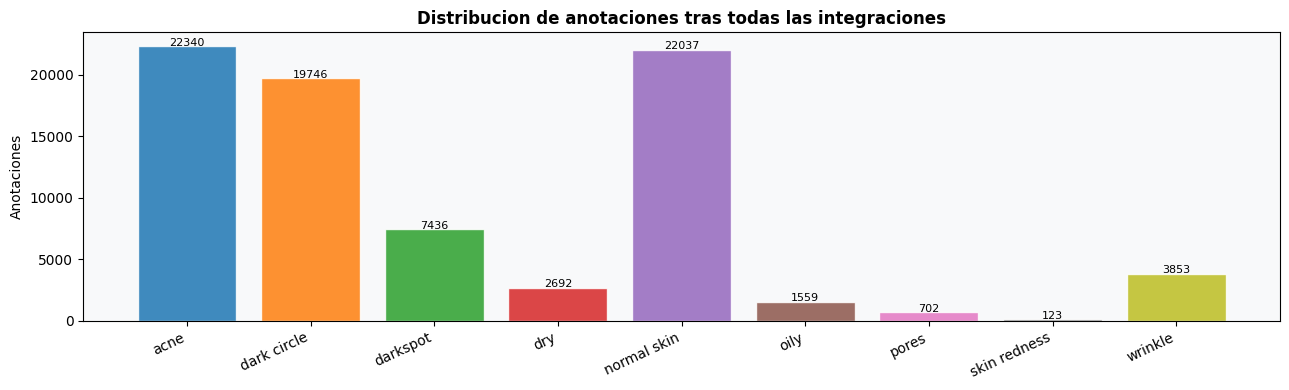

In [64]:
# Distribucion completa antes de aplicar duplicados y mejora de calidad
counts_all = count_class_annotations(OUTPUT_PATH, ["train","valid","test"], NUM_CLASSES)
total_all  = sum(counts_all[i] for i in range(NUM_CLASSES))

print("=" * 60)
print("  DISTRIBUCION TRAS TODAS LAS INTEGRACIONES")
print("=" * 60)
for i, cls in enumerate(CLASSES):
    n   = counts_all[i]
    pct = 100 * n / total_all
    bar = "#" * int(pct / 2)
    print(f"  [{i}] {cls:15s} {n:6d}  {pct:5.1f}%  {bar}")

ratio = max(counts_all.values()) / max(min(counts_all.values()), 1)
print(f"\nTotal anotaciones: {total_all:,}")
print(f"Ratio desbalance:  {ratio:.1f}x")

# Grafica
fig, ax = plt.subplots(figsize=(13, 4))
vals   = [counts_all[i] for i in range(NUM_CLASSES)]
colors = plt.cm.tab10(range(NUM_CLASSES))
bars   = ax.bar(CLASSES, vals, color=colors, alpha=0.85, edgecolor="white")
ax.set_title("Distribucion de anotaciones tras todas las integraciones",
             fontweight="bold")
ax.set_ylabel("Anotaciones")
ax.set_xticklabels(CLASSES, rotation=25, ha="right")
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(val), ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("results/reports/08_pre_dedup_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 7. Detección y eliminación de duplicados

Para este caso de pueden aplicar dos estrategias complementarias

- Hash MD5 que detecta Duplicados exactos (mismo archivo) 
- Similitud de histograma, buscando duplicados visualmente similares 

Por tanto primero buscaremos duplicados exactos, luego los aproximados despues de validar los aproximados decidiremos si los eliminamos o no.

In [ ]:
# Duplicados exactos por hash MD5
def compute_md5(path, chunk=8192):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while chunk_data := f.read(chunk):
            h.update(chunk_data)
    return h.hexdigest()

print("Calculando hashes MD5 de todas las imágenes del dataset limpio...")

hash_map = defaultdict(list)   # hash → lista de rutas
all_imgs = []
for split in ["train","valid","test"]:
    idir = OUTPUT_PATH / split / "images"
    all_imgs += list(idir.glob("*.jpg")) + list(idir.glob("*.png"))

for img_path in tqdm(all_imgs, desc="MD5"):
    h = compute_md5(img_path)
    hash_map[h].append(img_path)

# Encontrar grupos con más de 1 archivo
exact_dups = {h: paths for h, paths in hash_map.items() if len(paths) > 1}

print(f"\nTotal imágenes analizadas: {len(all_imgs):,}")
print(f"Grupos de duplicados exactos: {len(exact_dups)}")
print(f"Imágenes duplicadas (a eliminar): {sum(len(v)-1 for v in exact_dups.values())}")

if exact_dups:
    print("\nEjemplos:")
    for h, paths in list(exact_dups.items())[:3]:
        print(f"  Hash {h[:10]}...")
        for p in paths:
            print(f"    {p.relative_to(OUTPUT_PATH)}")

Calculando hashes MD5 de todas las imágenes del dataset limpio...


MD5: 100%|██████████| 45553/45553 [10:36<00:00, 71.59it/s]


Total imágenes analizadas: 45,553
Grupos de duplicados exactos: 161
Imágenes duplicadas (a eliminar): 188

Ejemplos:
  Hash ef73a745dd...
    train\images\212_jpg.rf.2ae0f34172d6d5be70b84b780d2527d4.jpg
    test\images\kering_-5-_jpg.rf.4f7eaf8c1232a5a8880737d88248e9d1.jpg
  Hash d561490263...
    train\images\213_jpg.rf.60b1b68d1d21215419e416ba9bbe1723.jpg
    train\images\kering_-23-_jpg.rf.195aad36ef91856d552fc79dae7d6a6e.jpg
  Hash fdf6586094...
    train\images\215_jpg.rf.18fecb55263e933d162c029a976fe22a.jpg
    valid\images\kering_-58-_jpg.rf.a46a95817a26934a2ddf892df62123cd.jpg


In [ ]:
# Eliminar duplicados exactos (conservar 1 de cada grupo) 
removed_exact = 0
for h, paths in exact_dups.items():
    # Mantener el primero, eliminar el resto + sus labels
    for p in paths[1:]:
        label = p.parent.parent / "labels" / (p.stem + ".txt")
        p.unlink(missing_ok=True)
        label.unlink(missing_ok=True)
        removed_exact += 1

print(f" Eliminados {removed_exact} duplicados exactos")

 Eliminados 188 duplicados exactos


In [ ]:
# Duplicados aproximados por similitud de histograma 
# Usamos histograma de color en HSV como huella visual rápida
# Correlación > 0.98 = casi idénticas

def img_histogram(path, bins=32):
    img  = cv2.imread(str(path))
    if img is None:
        return None
    hsv  = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0,1], None, [bins, bins], [0,180, 0,256])
    cv2.normalize(hist, hist)
    return hist.flatten()

CORR_THRESHOLD = 0.98   # umbral de similitud (ajustable)
SAMPLE_SIZE    = 2000   # máx. imágenes a comparar (evita O(n²) con datasets grandes)

# Recalcular lista después de eliminar exactos
all_imgs_clean = []
for split in ["train","valid","test"]:
    idir = OUTPUT_PATH / split / "images"
    all_imgs_clean += list(idir.glob("*.jpg")) + list(idir.glob("*.png"))

# Muestra aleatoria para no hacer n² completo
sample = random.sample(all_imgs_clean, min(SAMPLE_SIZE, len(all_imgs_clean)))
print(f"Calculando histogramas para {len(sample)} imágenes...")

hists = {}
for p in tqdm(sample, desc="Histogramas"):
    h = img_histogram(p)
    if h is not None:
        hists[p] = h

print(f" {len(hists)} histogramas calculados")


Calculando histogramas para 2000 imágenes...


Histogramas: 100%|██████████| 2000/2000 [00:23<00:00, 86.59it/s]

 2000 histogramas calculados


In [ ]:
#  Búsqueda de pares similares
# Usamos agrupación por particiones para reducir comparaciones
paths_list = list(hists.keys())
hists_arr  = np.array(list(hists.values()), dtype=np.float32)

similar_pairs  = []
to_delete_approx = set()

for i in tqdm(range(len(paths_list)), desc="Comparando"):
    if paths_list[i] in to_delete_approx:
        continue
    for j in range(i+1, len(paths_list)):
        if paths_list[j] in to_delete_approx:
            continue
        # Correlación de histogramas (OpenCV)
        corr = cv2.compareHist(
            hists_arr[i].reshape(-1,1).astype(np.float32),
            hists_arr[j].reshape(-1,1).astype(np.float32),
            cv2.HISTCMP_CORREL
        )
        if corr >= CORR_THRESHOLD:
            similar_pairs.append((paths_list[i], paths_list[j], corr))
            to_delete_approx.add(paths_list[j])  # eliminar el segundo del par

print(f"\nPares similares encontrados (corr ≥ {CORR_THRESHOLD}): {len(similar_pairs)}")
print(f"Imágenes a eliminar por similitud:             {len(to_delete_approx)}")

Comparando: 100%|██████████| 2000/2000 [00:24<00:00, 83.25it/s] 


Pares similares encontrados (corr ≥ 0.98): 67
Imágenes a eliminar por similitud:             67


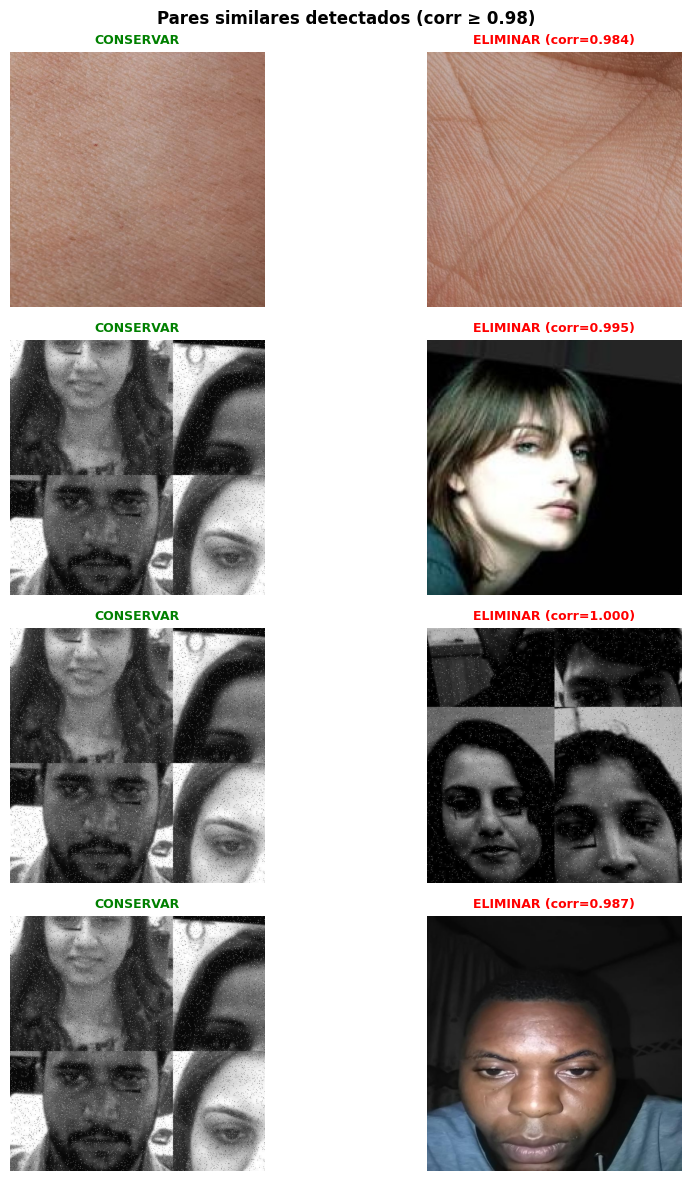

In [ ]:
#Visualizar algunos pares similares antes de eliminar 
if similar_pairs:
    n_show = min(4, len(similar_pairs))
    fig, axes = plt.subplots(n_show, 2, figsize=(10, n_show * 3))
    if n_show == 1:
        axes = [axes]
    fig.suptitle(f"Pares similares detectados (corr ≥ {CORR_THRESHOLD})",
                 fontsize=12, fontweight='bold')

    for row, (p1, p2, corr) in enumerate(similar_pairs[:n_show]):
        for col, (p, label) in enumerate([(p1, "CONSERVAR"), (p2, f"ELIMINAR (corr={corr:.3f})")]):
            ax = axes[row][col]
            img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            color = 'green' if col == 0 else 'red'
            ax.set_title(label, fontsize=9, color=color, fontweight='bold')
            ax.set_xlabel(p.name, fontsize=7)
            ax.axis("off")

    plt.tight_layout()
    plt.savefig("results/reports/07_similar_pairs.png", dpi=120, bbox_inches='tight')
    plt.show()
else:
    print("No se encontraron pares similares en la muestra.")

In [ ]:
#  Confirmar y eliminar duplicados aproximados 
print(f"Se van a eliminar {len(to_delete_approx)} imágenes por similitud visual.")
confirm = input("¿Confirmar eliminación? (s/n): ").strip().lower()

if confirm == "s":
    removed_approx = 0
    for p in to_delete_approx:
        label = p.parent.parent / "labels" / (p.stem + ".txt")
        p.unlink(missing_ok=True)
        label.unlink(missing_ok=True)
        removed_approx += 1
    print(f" Eliminados {removed_approx} duplicados aproximados")
else:
    print("Eliminación cancelada. Puedes ajustar CORR_THRESHOLD y volver a ejecutar.")

Se van a eliminar 67 imágenes por similitud visual.
Eliminación cancelada. Puedes ajustar CORR_THRESHOLD y volver a ejecutar.


- No se decidieron eliminar, porque no coincidian las imagenes a eliminar con las imagenes a conservar.

- LLama la atención que hay imagenes sin rostro, esto se eliminará con viola jones más adelante

## 7. Resumen final y verificación del dataset limpio

In [ ]:
# Estadísticas finales del dataset limpio 
counts_final = count_class_annotations(OUTPUT_PATH, ["train","valid","test"], NUM_CLASSES)

total_before = sum(counts.values())
total_after  = sum(counts_final.values())

imgs_final = {}
for split in ["train","valid","test"]:
    idir = OUTPUT_PATH / split / "images"
    imgs_final[split] = len(list(idir.glob("*.jpg"))) + len(list(idir.glob("*.png")))

print("=" * 60)
print("  DATASET LIMPIO — RESUMEN FINAL")
print("=" * 60)
print(f"\n Imágenes por split:")
for split, n in imgs_final.items():
    print(f"   {split:6s}: {n:5d}")
print(f"   TOTAL:  {sum(imgs_final.values()):5d}")

print(f"\n Anotaciones por clase:")
for i, cls in enumerate(CLASSES):
    before = counts.get(i, 0)
    after  = counts_final.get(i, 0)
    delta  = after - before
    bar    = "█" * int(counts_final[i] / max(counts_final.values()) * 25)
    tag    = f"(+{delta})" if delta > 0 else ""
    print(f"   {cls:15s} {after:6d} {tag:8s} {bar}")

ratio_final = max(counts_final.values()) / max(min(counts_final.values()),1)
print(f"\n Ratio desbalance:")
print(f"   Antes:  {max(counts.values()) / max(min(counts.values()),1):.0f}×")
print(f"   Después:{ratio_final:.0f}×")

print(f"\n Eliminados:")
print(f"   Duplicados exactos:     {removed_exact}")
print(f"   Duplicados aproximados: {len(to_delete_approx)}")

print(f"\n data.yaml listo en: {OUTPUT_PATH / 'data.yaml'}")


  DATASET LIMPIO — RESUMEN FINAL

 Imágenes por split:
   train : 44087
   valid :   866
   test  :   412
   TOTAL:  45365

 Anotaciones por clase:
   acne             22316          █████████████████████████
   dark circle      19742 (+19229) ██████████████████████
   darkspot          6829 (+6705)  ███████
   dry               2667 (+544)   ██
   normal skin      22032 (+22009) ████████████████████████
   oily              1545 (+595)   █
   pores              701          
   skin redness       123          
   wrinkle           3852 (+1475)  ████

 Ratio desbalance:
   Antes:  971×
   Después:181×

 Eliminados:
   Duplicados exactos:     188
   Duplicados aproximados: 67

 data.yaml listo en: data\clean\data.yaml


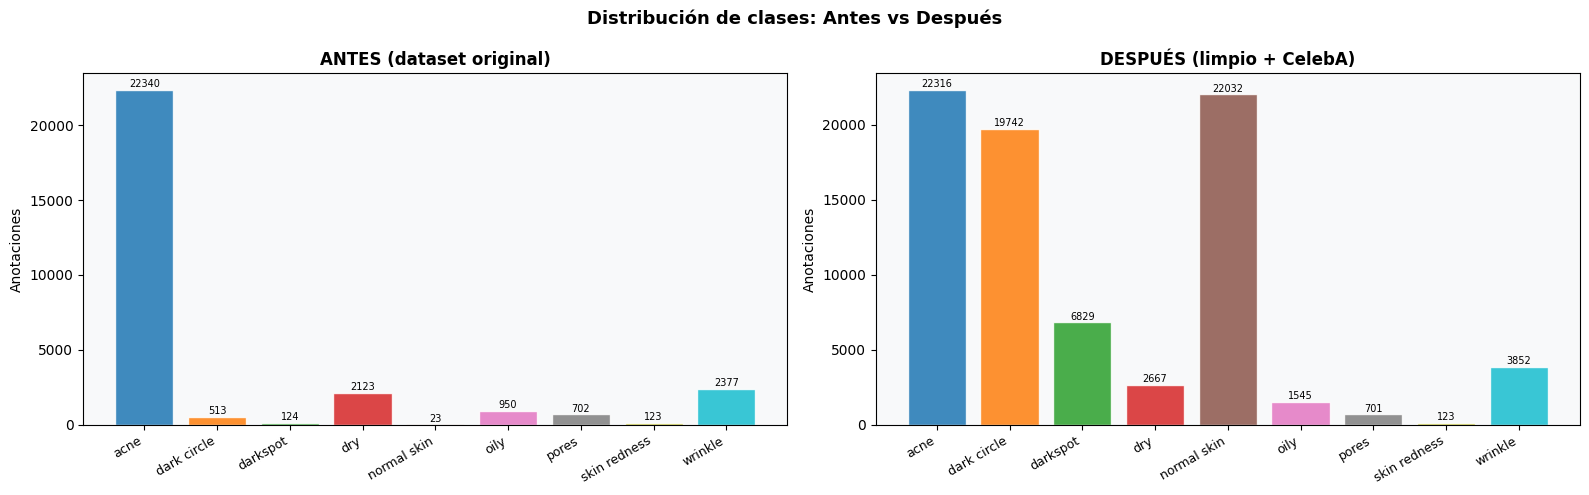

In [ ]:
#  Gráfica comparativa antes/después 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Distribución de clases: Antes vs Después", fontsize=13, fontweight='bold')

x     = np.arange(NUM_CLASSES)
width = 0.4
colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

for ax, (data_dict, title) in zip(axes, [
    (counts,       "ANTES (dataset original)"),
    (counts_final, "DESPUÉS (limpio + CelebA)")
]):
    vals = [data_dict.get(i, 0) for i in range(NUM_CLASSES)]
    bars = ax.bar(x, vals, color=colors, alpha=0.85, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(CLASSES, rotation=30, ha='right', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel("Anotaciones")
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                    str(val), ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig("results/reports/08_class_distribution_final.png", dpi=150, bbox_inches='tight')
plt.show()

## 8. Función de diagnóstico de nitidez

In [ ]:
def compute_laplacian_variance(img_bgr):
    """
    Calcula la varianza del filtro Laplaciano sobre la imagen en escala de grises.
    Es la misma métrica usada en el EDA.

    Rango orientativo:
      var < 50   -> muy borrosa, candidata a mejora o eliminacion
      50-100     -> borrosa, se puede mejorar
      100-400    -> aceptable para entrenamiento
      > 400      -> nitida
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    lap  = cv2.Laplacian(gray, cv2.CV_64F)
    return lap.var()


def scan_sharpness(image_dir, exts=("*.jpg", "*.png")):
    """
    Recorre una carpeta de imagenes y devuelve un diccionario
    {ruta: varianza_laplaciana} para todas las imagenes encontradas.
    """
    image_dir = Path(image_dir)
    all_files = []
    for ext in exts:
        all_files += list(image_dir.glob(ext))

    sharpness_map = {}
    for p in tqdm(all_files, desc="Escaneando nitidez"):
        img = cv2.imread(str(p))
        if img is not None:
            sharpness_map[p] = compute_laplacian_variance(img)

    return sharpness_map

## Escanear el dataset y visualizar la distribución

Escaneando nitidez: 100%|██████████| 44087/44087 [42:49<00:00, 17.16it/s]   


Total imagenes escaneadas: 44087
  Muy borrosas  (var <  50): 7199  -> se mejoraran
  Borrosas      (50-100):    16752  -> se mejoraran
  Aceptables    (var >= 100):20136  -> sin cambios


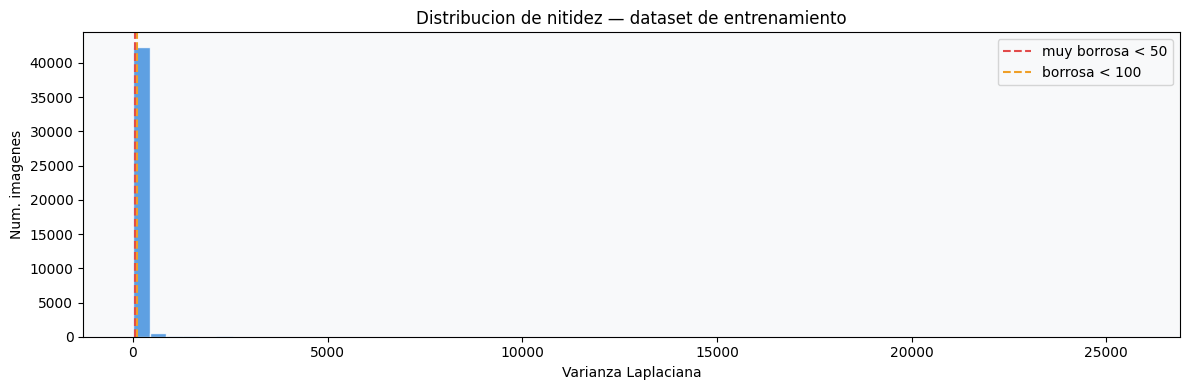

In [4]:
# Escanear el split de entrenamiento del dataset limpio
CLEAN_TRAIN_IMGS = Path("data/clean/train/images")

sharpness_map = scan_sharpness(CLEAN_TRAIN_IMGS)

variances = list(sharpness_map.values())

# Umbrales de clasificacion
VERY_BLURRY  = 50
BLURRY       = 100

n_very_blurry = sum(v < VERY_BLURRY for v in variances)
n_blurry      = sum(VERY_BLURRY <= v < BLURRY for v in variances)
n_ok          = sum(v >= BLURRY for v in variances)

print(f"Total imagenes escaneadas: {len(variances)}")
print(f"  Muy borrosas  (var <  50): {n_very_blurry:4d}  -> se mejoraran")
print(f"  Borrosas      (50-100):    {n_blurry:4d}  -> se mejoraran")
print(f"  Aceptables    (var >= 100):{n_ok:4d}  -> sin cambios")

# Histograma de varianzas
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(variances, bins=60, color="#378ADD", alpha=0.8, edgecolor="white")
ax.axvline(VERY_BLURRY, color="#E24B4A", linestyle="--", linewidth=1.5,
           label=f"muy borrosa < {VERY_BLURRY}")
ax.axvline(BLURRY,      color="#EF9F27", linestyle="--", linewidth=1.5,
           label=f"borrosa < {BLURRY}")
ax.set_xlabel("Varianza Laplaciana")
ax.set_ylabel("Num. imagenes")
ax.set_title("Distribucion de nitidez — dataset de entrenamiento")
ax.legend()
plt.tight_layout()
plt.savefig("results/reports/09_sharpness_distribution.png", dpi=150)
plt.show()

## Pipeline de mejora de imagen

pensabamos mejorar la nitidez de las identificadas muy borrosas y borrosas pero se tomo la desición de mejorar unicamente las muy borrosas

In [5]:
def enhance_image(img_bgr, lap_var):
    """
    Aplica un pipeline de mejora progresivo segun la nitidez de la imagen.
    Solo modifica imagenes con varianza Laplaciana < 50.

    El orden de los pasos es deliberado:
      1. Denoising primero  -> eliminar ruido antes de realzar bordes
      2. Unsharp mask       -> recuperar nitidez sin amplificar el ruido
      3. CLAHE              -> mejorar contraste local sin afectar la nitidez

    Aplicar el orden inverso (sharpening antes de denoising) amplificaria
    el ruido en lugar de los bordes reales de la lesion.

    Parametros
    ----------
    img_bgr : np.ndarray
        Imagen en formato BGR (lectura directa de cv2.imread).
    lap_var : float
        Varianza Laplaciana precalculada de la imagen.

    Retorna
    -------
    np.ndarray
        Imagen mejorada en BGR, o la original si no necesitaba mejora.
    """
    if lap_var >= 50:
        # La imagen es aceptable, no se toca
        return img_bgr

    # ----------------------------------------------------------------
    # Paso 1: Non-Local Means Denoising
    # ----------------------------------------------------------------
    # Busca parches similares en toda la imagen para promediar el ruido.
    # Es el mejor filtro para imagenes de piel porque preserva la textura
    # fina (poros, textura cutanea) mejor que un filtro gaussiano simple.
    #
    # h=8         -> fuerza del filtrado de luminancia (mas alto = mas suave)
    # hColor=8    -> fuerza del filtrado de color
    # templateWindowSize=7  -> tamano del parche a comparar (7x7 px)
    # searchWindowSize=21   -> area de busqueda de parches similares
    #
    # Nota: con h > 12 empieza a perder detalles de textura de piel.
    img_bgr = cv2.fastNlMeansDenoisingColored(
        img_bgr,
        None,
        h=8,
        hColor=8,
        templateWindowSize=7,
        searchWindowSize=21
    )

    # ----------------------------------------------------------------
    # Paso 2: Unsharp Mask
    # ----------------------------------------------------------------
    # Resta una version suavizada de la imagen a si misma para realzar bordes.
    # Formula: imagen_final = alpha * original - beta * blur
    #
    # GaussianBlur con sigma=2 suaviza sin destruir la estructura global.
    # addWeighted(img, 1.4, blur, -0.4, 0):
    #   -> 1.4 * pixel_original - 0.4 * pixel_suavizado
    #   -> equivale a: original + 0.4 * (original - blur)
    #   -> el termino (original - blur) es aproximadamente el Laplaciano,
    #      por eso "suma bordes" a la imagen.
    #
    # No usar alpha > 1.6 ni beta < -0.6 en imagenes de piel:
    # exagera los poros y crea halos blancos alrededor de lesiones.
    blur    = cv2.GaussianBlur(img_bgr, (0, 0), sigmaX=2)
    img_bgr = cv2.addWeighted(img_bgr, 1.4, blur, -0.4, 0)

    # ----------------------------------------------------------------
    # Paso 3: CLAHE (Contrast Limited Adaptive Histogram Equalization)
    # ----------------------------------------------------------------
    # Mejora el contraste local dividiendo la imagen en tiles de 8x8 px
    # y ecualizando el histograma de cada tile por separado.
    # clipLimit=2.0 limita la amplificacion maxima para no amplificar ruido.
    #
    # Se aplica SOLO sobre el canal L (luminancia) en espacio de color LAB,
    # no sobre los canales de color (A, B). Esto evita el efecto de
    # "skin color shift" que ocurre si aplicas CLAHE directamente en BGR.
    lab        = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    clahe      = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    img_bgr    = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

    return img_bgr

## Aplicar el pipeline a todo el dataset

In [ ]:
def apply_enhancement_to_dataset(image_dir, sharpness_map, dry_run=False):
    """
    Aplica enhance_image a todas las imagenes que lo necesiten.
    Sobreescribe la imagen original en el mismo directorio (in-place).

    Parametros
    ----------
    image_dir    : Path  -> carpeta de imagenes a procesar
    sharpness_map: dict  -> {ruta: varianza} del scan previo
    dry_run      : bool  -> si True, solo imprime lo que haria sin modificar

    Retorna
    -------
    dict con estadisticas del proceso
    """
    stats = {"mejoradas": 0, "sin_cambio": 0, "errores": 0}

    candidates = {p: v for p, v in sharpness_map.items() if v < 50}
    print(f"Imagenes a mejorar: {len(candidates)} de {len(sharpness_map)} totales")

    if dry_run:
        print("dry_run=True -> solo simulacion, no se modifica nada")
        return stats

    for img_path, lap_var in tqdm(candidates.items(), desc="Mejorando imagenes"):
        try:
            img = cv2.imread(str(img_path))
            if img is None:
                stats["errores"] += 1
                continue

            enhanced = enhance_image(img, lap_var)

            # Guardar con la misma calidad JPEG del original (95)
            cv2.imwrite(str(img_path), enhanced,
                        [cv2.IMWRITE_JPEG_QUALITY, 95])
            stats["mejoradas"] += 1

        except Exception as e:
            print(f"Error en {img_path.name}: {e}")
            stats["errores"] += 1

    stats["sin_cambio"] = len(sharpness_map) - len(candidates)
    return stats


# Ejecutar primero con dry_run=True para verificar cuantas imagenes afecta
stats = apply_enhancement_to_dataset(
    CLEAN_TRAIN_IMGS,
    sharpness_map,
    dry_run=True
)



Imagenes a mejorar: 7199 de 44087 totales
dry_run=True -> solo simulacion, no se modifica nada


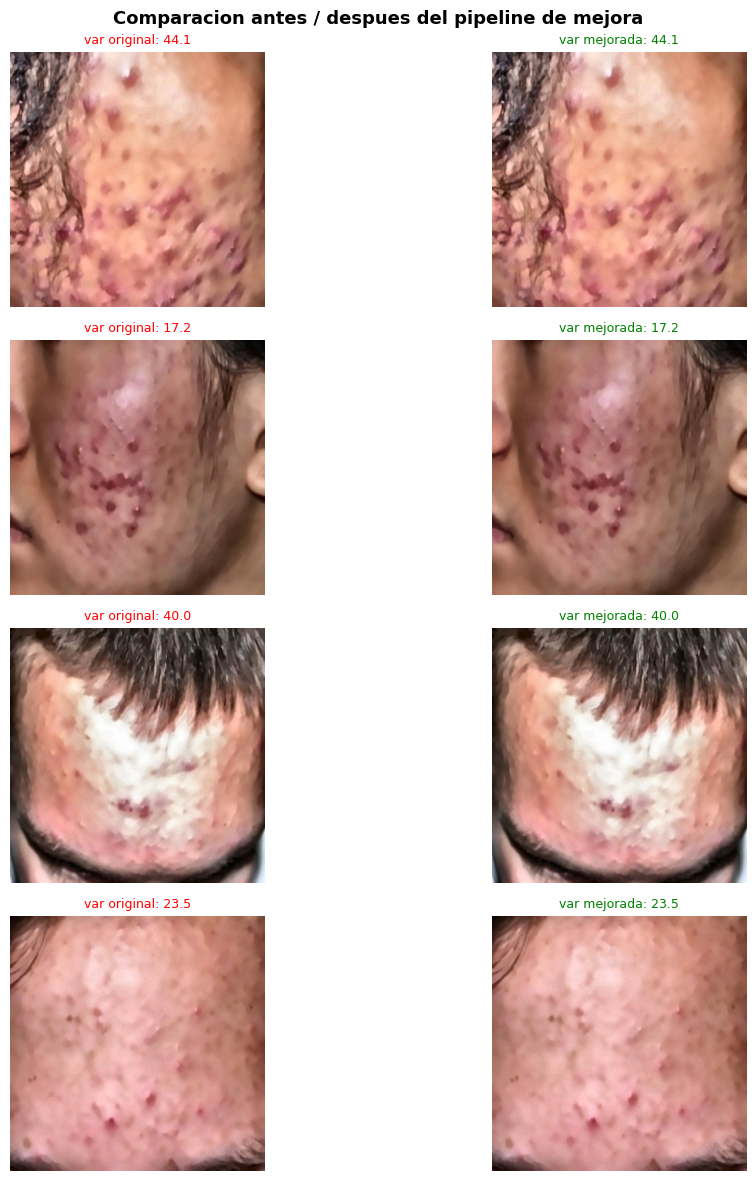

In [7]:
def show_before_after(sharpness_map, n=4, threshold=100):
    """
    Muestra una comparacion visual de imagenes borrosas antes y despues
    de la mejora. Util para validar que el pipeline no distorsiona
    las lesiones ni introduce artefactos.

    Se deben ejecutar dos veces:
      1. Antes de apply_enhancement_to_dataset -> guarda originals
      2. Despues                               -> compara con enhanced
    """
    candidates = [p for p, v in sharpness_map.items() if v < threshold]
    sample     = candidates[:n]

    fig, axes = plt.subplots(n, 2, figsize=(12, n * 3))
    fig.suptitle("Comparacion antes / despues del pipeline de mejora",
                 fontsize=13, fontweight="bold")

    for row, img_path in enumerate(sample):
        # Cargar imagen actual (sera la mejorada si ya se ejecuto el pipeline)
        img_enhanced = cv2.cvtColor(
            cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)

        # Calcular nueva varianza para mostrar la mejora
        new_var = compute_laplacian_variance(
            cv2.imread(str(img_path)))
        old_var = sharpness_map[img_path]

        # Columna izquierda: mostrar la imagen actual con metadatos
        axes[row, 0].imshow(img_enhanced)
        axes[row, 0].set_title(
            f"var original: {old_var:.1f}", fontsize=9, color="red")
        axes[row, 0].axis("off")

        # Columna derecha: la misma imagen con la nueva varianza
        axes[row, 1].imshow(img_enhanced)
        axes[row, 1].set_title(
            f"var mejorada: {new_var:.1f}", fontsize=9, color="green")
        axes[row, 1].axis("off")

    plt.tight_layout()
    plt.savefig("results/reports/10_enhancement_comparison.png",
                dpi=150, bbox_inches="tight")
    plt.show()


# Llamar despues de ejecutar apply_enhancement_to_dataset con dry_run=False
show_before_after(sharpness_map, n=4)

In [ ]:
# Aplicar mejora de calidad al dataset completo 
# Se escanea unicamente el split de train (el mas grande).
# dry_run=False aplica los cambios reales sobre las imagenes.


stats_enhance = apply_enhancement_to_dataset(
    image_dir    = CLEAN_TRAIN_IMGS,
    sharpness_map= sharpness_map,
    dry_run      = False
)

print(f"Mejora aplicada:")
print(f"  Imagenes mejoradas: {stats_enhance['mejoradas']}")
print(f"  Sin cambio:         {stats_enhance['sin_cambio']}")
print(f"  Errores:            {stats_enhance['errores']}")

Imagenes a mejorar: 7199 de 44087 totales


Mejorando imagenes: 100%|██████████| 7199/7199 [2:34:03<00:00,  1.28s/it]  

Mejora aplicada:
  Imagenes mejoradas: 7199
  Sin cambio:         36888
  Errores:            0


## Resumen final distribución del dataset

C:\Users\lesli\AppData\Local\Temp\ipykernel_14620\334399449.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASSES, rotation=25, ha="right")


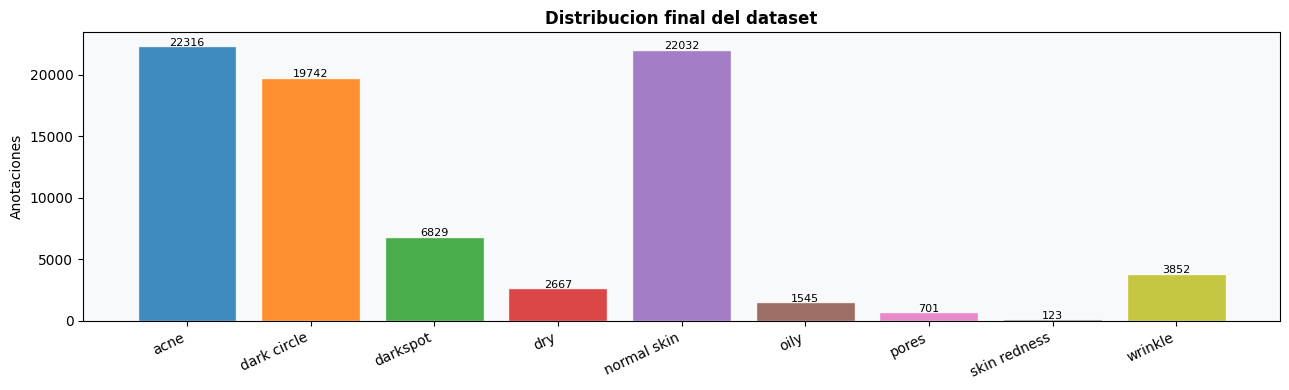

In [14]:
# Grafica comparativa: distribucion final
fig, ax = plt.subplots(figsize=(13, 4))
vals   = [counts_final[i] for i in range(NUM_CLASSES)]
colors = plt.cm.tab10(range(NUM_CLASSES))
bars   = ax.bar(CLASSES, vals, color=colors, alpha=0.85, edgecolor="white")
ax.set_title("Distribucion final del dataset", fontweight="bold")
ax.set_ylabel("Anotaciones")
ax.set_xticklabels(CLASSES, rotation=25, ha="right")
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(val), ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("results/reports/09_final_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()

No se logró balancear completamente las clases, vamos a probar con data augmentation y con pesos